# Asset allocation with fully flexible views

## Import relevant packages

In [2]:
"""
Magic commands
"""

%load_ext autoreload
%autoreload 2

"""
Python packages
"""

import numpy as np
from scipy import stats, optimize
import pandas as pd
import matplotlib.pyplot as plt

from typing import List, Union

"""
Own packages
"""

import sys
sys.path.insert(0,'C:\\code\\python_for_the_financial_economist\\')

from codelib.visualization.layout import DefaultStyle, default_colors
DefaultStyle();

from codelib.visualization.base import fan_chart, risk_waterfall_chart, waterfall_chart

# Views
import codelib.statistics.fully_flexible_views as ffv

#import ProbabilitySolver, MeanView, VolatilityView, effective_sample_size_entropy

from codelib.statistics.moments import weighted_percentile


import codelib.statistics.moments as mom
import codelib.portfolio_optimization.risk_metrics as rm
import codelib.portfolio_optimization.risk_budget as rb

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Simple simulation model

We assume that 

$$
\log (1  + \mathbf{R}) \sim N(\boldsymbol{\mu}, \boldsymbol{\Sigma})
$$

In [3]:
"""
Define input values - consistent with specification in Munk and Rangvid
"""


asset_names = ["Government bonds", "Investment-grade bonds", "High-yield bonds",
               "Emerging markets gov. bonds", "Equities (developed markets)",
               "Equities (Emerging markets)", "Private equity", "Infrastructure",
               "Real Estate", "Hedgefunds"]

corr_mat = np.array([[1.00, 0.60, 0.10, 0.30, -0.10, -0.10, -0.20, -0.10, -0.10, -0.10],
                     [0.60, 1.00, 0.60, 0.60, 0.20, 0.20, 0.20, 0.10, 0.10, 0.30],
                     [0.10, 0.60, 1.00, 0.70, 0.70, 0.60, 0.60, 0.40, 0.30, 0.70],
                     [0.30, 0.60, 0.70, 1.00, 0.50, 0.60, 0.40, 0.20, 0.20, 0.50],
                     [-0.10, 0.20, 0.70, 0.50, 1.00, 0.70, 0.80, 0.40, 0.40, 0.80],
                     [-0.10, 0.20, 0.60, 0.60, 0.70, 1.00, 0.70, 0.40, 0.40, 0.70],
                     [-0.20, 0.20, 0.60, 0.40, 0.80, 0.70, 1.00, 0.40, 0.40, 0.70],
                     [-0.10, 0.10, 0.40, 0.20, 0.40, 0.40, 0.40, 1.00, 0.30, 0.40],
                     [-0.10, 0.10, 0.30, 0.20, 0.40, 0.40, 0.40, 0.30, 1.00, 0.40],
                     [-0.10, 0.30, 0.70, 0.50, 0.80, 0.70, 0.70, 0.40, 0.40, 1.00]])

vols = np.array([3.7, 5.5, 11.9, 10.7, 15.3, 21.7, 20.4, 14.0, 10.8, 9.4]) / 100.0

cov_mat = mom.corr_to_cov_matrix(corr_mat=corr_mat, vols=vols)

mu = np.array([1.9, 2.2, 4.9, 4.3, 6.1, 8.3, 10.2, 5.6, 4.1, 3.8]) / 100 - 0.5 * vols**2 

num_assets = len(mu)

In [4]:
"""
Simulate asset prices
"""

time_step = 1.0 / 12.0
num_periods = 60
time_points = np.arange(0, 5.0 + time_step, time_step)
num_sim = int(1e4)

sim_prices = np.ones((num_sim, num_periods + 1, num_assets))

sim_prices[:, 1:, :] = np.exp(np.cumsum(np.random.multivariate_normal(mu * time_step, cov_mat * time_step,
                                                            size=(num_sim, num_periods)), axis=1))


In [5]:
"""
Simulate portfolio values 
"""

# equally weighted portfolio
eq_w = np.ones(len(mu)) / len(mu)

sim_port_values = sim_prices @ eq_w

In [6]:
"""
Calculate CVaR and VaR - 1Y
"""
print("VaR: {}".format(-rm.calculate_value_at_risk(sim_port_values[:, 12] - 1.0, p = 0.05)))
print("CVaR: {}".format(-rm.calculate_conditional_value_at_risk(sim_port_values[:, 12] - 1.0, p = 0.05)))

VaR: 0.09315611582759574
CVaR: 0.12421615123922687


In [7]:
cvar_risk_contribs = rb.calculate_risk_contributions_cvar(eq_w, sim_prices[:, 12] - 1.0, p=0.05) * 100

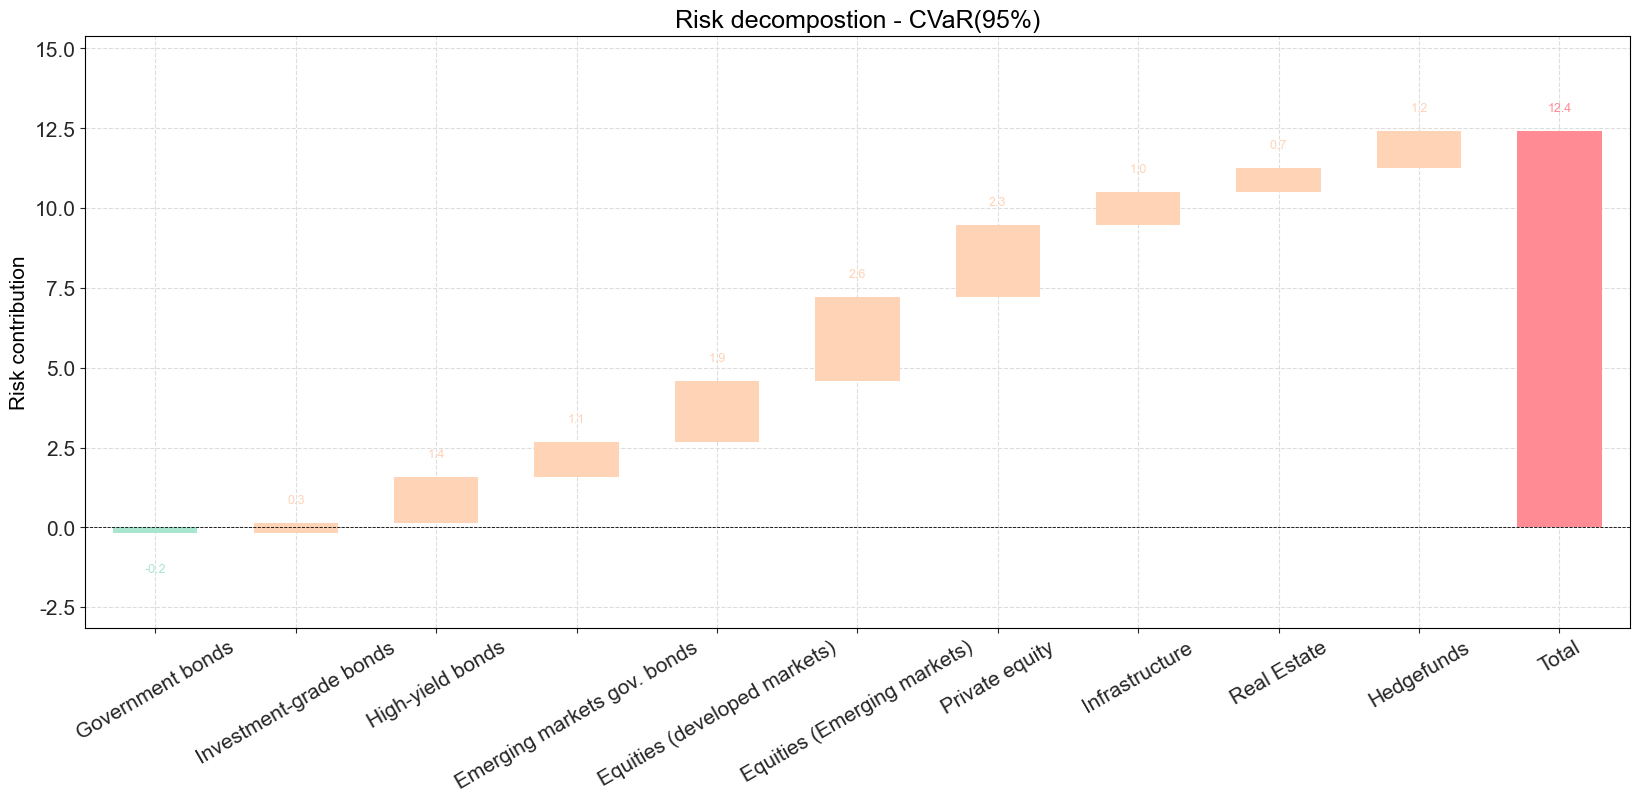

In [8]:
waterfall_chart(labels=asset_names, values=-cvar_risk_contribs)

fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(18.5, 10.5)
ax.set_title('Risk decompostion - CVaR(95%)')
ax.set_ylabel('Risk contribution'); 

## Implementing views

In [9]:
hor = 12 # 12 months 
init_probs = np.ones(num_sim) / num_sim

### View on expected government bond return

In [10]:
gov_mean_view = ffv.MeanView(view_type='leq', factor=sim_prices[:, 12, 0] - 1.0, mean_target=-0.02)

all_views = [gov_mean_view]

# solve for probabilities
view_solver = ffv.ProbabilitySolver(init_probs, all_views)
gov_view_probs = view_solver.minimize_entropy()

In [12]:
ffv.effective_sample_size_entropy(gov_view_probs, relative=True)

0.5669383766381605

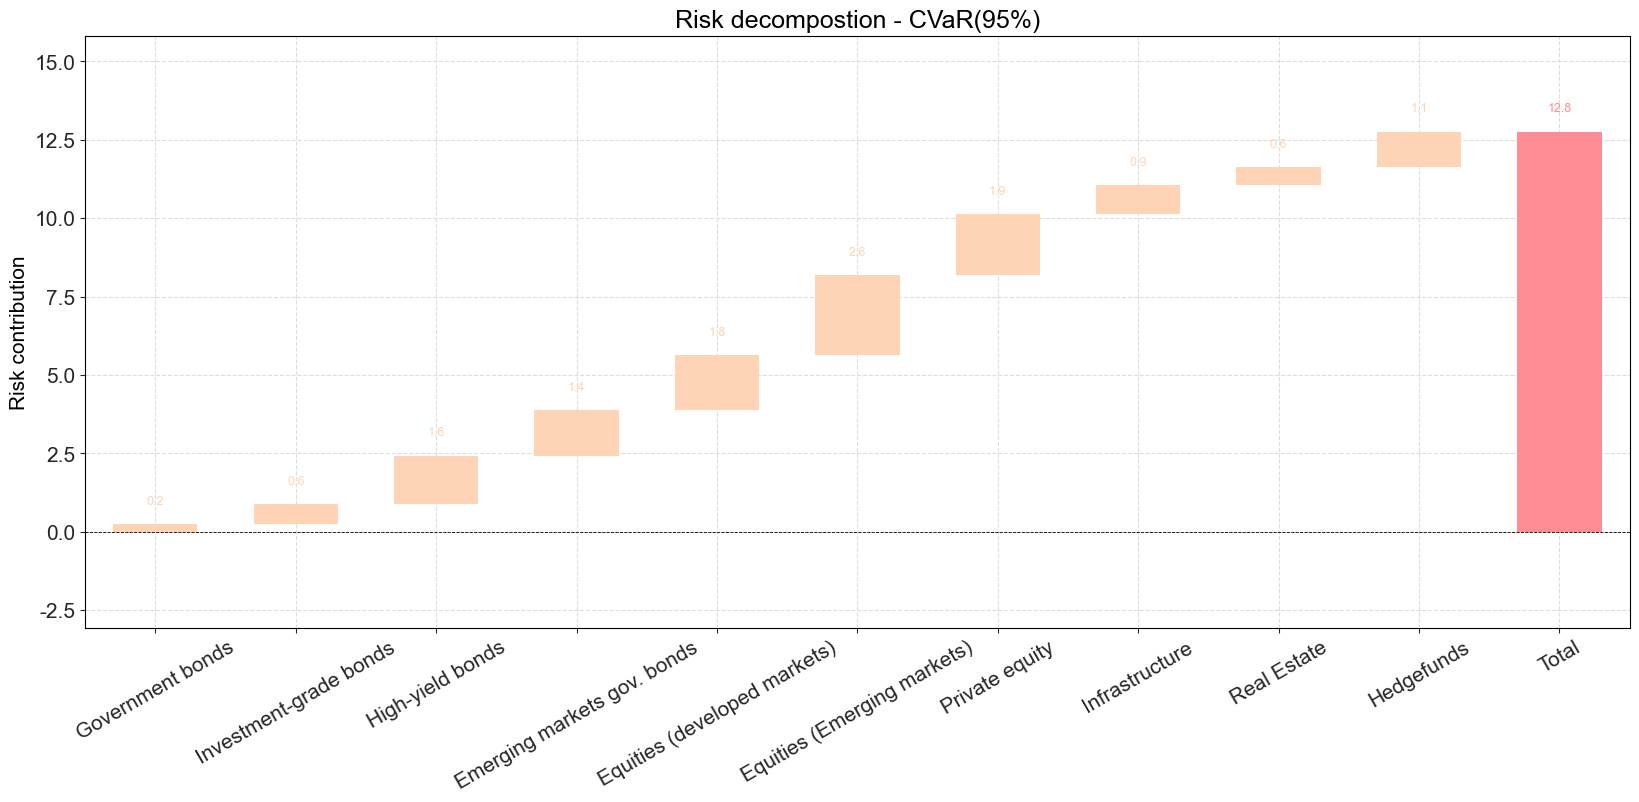

In [13]:
cvar_risk_contribs = rb.calculate_risk_contributions_cvar(eq_w, sim_prices[:, 12] - 1.0, p=0.05, probs=gov_view_probs) * 100

waterfall_chart(labels=asset_names, values=-cvar_risk_contribs)

fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(18.5, 10.5)
ax.set_title('Risk decompostion - CVaR(95%)')
ax.set_ylabel('Risk contribution'); 

### View on correlation

In [14]:
gov_mean_view = ffv.MeanView(view_type='eq',
                             factor=sim_prices[:, hor, 0] - 1.0,
                             mean_target=np.mean(sim_prices[:, hor, 0] - 1.0))

eq_mean_view = ffv.MeanView(view_type='eq',
                            factor=sim_prices[:, hor, 4] - 1.0,
                            mean_target=np.mean(sim_prices[:, hor, 4] - 1.0))


gov_vol_view = ffv.VolatilityView(view_type='eq',
                                   factor=sim_prices[:, hor, 0] - 1.0,
                                   expected_value=gov_mean_view.constraint_vector,
                                   vol_target=np.std(sim_prices[:, hor, 0] - 1.0))

eq_vol_view = ffv.VolatilityView(view_type='eq',
                                  factor=sim_prices[:, hor, 4] - 1.0,
                                  expected_value=eq_mean_view.constraint_vector,
                                  vol_target=np.std(sim_prices[:, hor, 4] - 1.0))

corr_view = ffv.CorrelationView(view_type='eq',
                                first_factor=sim_prices[:, hor, 0] - 1.0,
                                second_factor=sim_prices[:, hor, 4] - 1.0,
                                first_expected_value=gov_mean_view.constraint_vector,
                                second_expected_value=eq_mean_view.constraint_vector,
                                first_vol=np.std(sim_prices[:, hor, 0] - 1.0),
                                second_vol=np.std(sim_prices[:, hor, 4] - 1.0),
                                correlation_target=0.7)


all_views = [gov_mean_view, eq_mean_view, gov_vol_view, eq_vol_view, corr_view]

# solve for probabilities
view_solver = ffv.ProbabilitySolver(init_probs, all_views)
corr_view_probs = view_solver.minimize_entropy()

In [15]:
ffv.effective_sample_size_entropy(corr_view_probs, relative=True)

0.6595492255879521

In [16]:
mom.calculate_correlation(sim_prices[:, 12, 4] - 1.0, sim_prices[:, 12, 0] - 1.0, probs=corr_view_probs)

0.6999981413189862

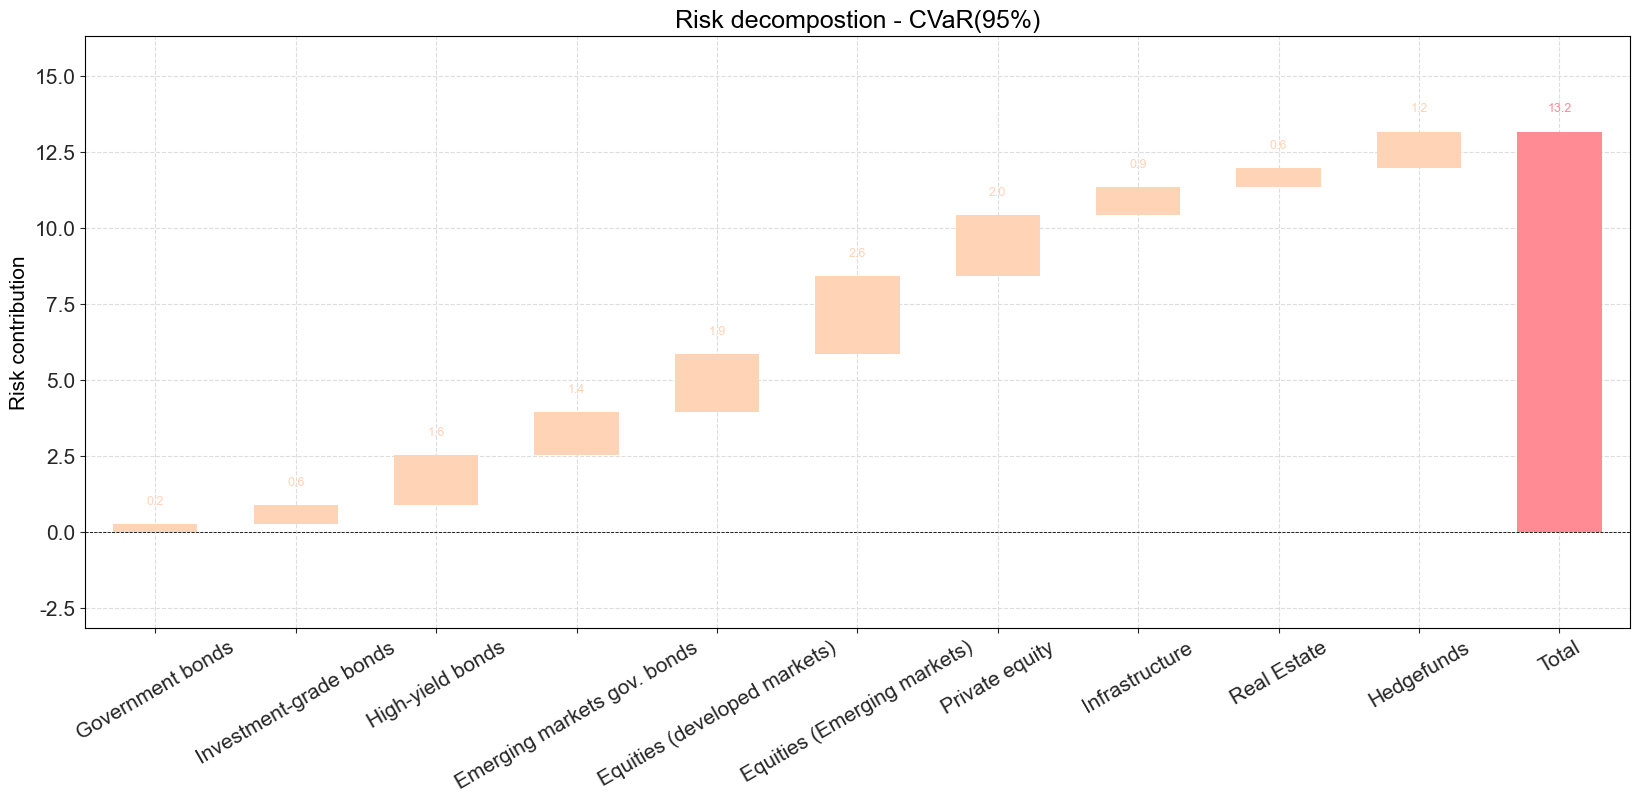

In [17]:
cvar_risk_contribs = rb.calculate_risk_contributions_cvar(eq_w, sim_prices[:, 12] - 1.0, p=0.05, probs=corr_view_probs) * 100

waterfall_chart(labels=asset_names, values=-cvar_risk_contribs)

fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(18.5, 10.5)
ax.set_title('Risk decompostion - CVaR(95%)')
ax.set_ylabel('Risk contribution'); 

In [18]:
gov_mean_view.constraint_vector

0.018914352622885832